In [ ]:
# importing pandas
import pandas as pd


Next we need to read the train.csv data that we dropped here. With head() we are given the first 5 results.

In [ ]:
df = pd.read_csv('train.csv', encoding='ISO-8859-1')
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


Next let's check if the data has null-values, which could cause problems later. We see that there is a couple: one in text-column and one on selected_text.

In [ ]:
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0
Time of Tweet,0
Age of User,0
Country,0
Population -2020,0
Land Area (Km²),0
Density (P/Km²),0


Let's remove those nulls.

In [ ]:
# inplace means this will replace the values in the same data table,
# which means we don't need to save it to a new variable
df.dropna(inplace=True)

# let's check again if there a re nulls with the code snippet above.
# Results: Zero nulls.


With describe we can see some basic data, like a mean value of the columns.

This seems to display only the strictly numeric values (which excludes the age gap column): population, land area and density.

In [ ]:
df.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,2.748000e+04,2.748000e+04,27480.000000
mean,4.018634e+07,6.621672e+05,357.699491
std,1.504972e+08,1.807457e+06,2013.786207
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.655535e+06,1.118900e+05,89.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


# Training
I think I should choose the columns for  *text* and *sentiment* for this. I should train the model with the *text* and compare the results with *sentiment* to see if the training went well. This means that the results for each text should correspond with the sentiment.

I chose to split the data so that 75% is used for training and 25% for testing. If I understood correctly, the random_state is a random value that will make sure the split is reproducible while being random.

In [ ]:
from sklearn.model_selection import train_test_split

# this seperates the columns from the original dataframe to seperate variables
text = df['text']
sentiment = df['sentiment']

text_train, text_test, sentiment_train, sentiment_test = train_test_split(text, sentiment, test_size=0.25, random_state=39)


Next we will actually train the model. This will vectorize and classify the data using packages from the sklearn import.

The Pipeline is an optional helper tool to run several steps in one coherent step.

The TfidfVectorizer does the vectorizing and the LinearSVC does the classification (linear)

Then we fit the data which basically is the training itself

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

text_classifier = Pipeline([
    ('vectorizing', TfidfVectorizer()),
    ('classification', LinearSVC())
])


text_classifier.fit(text_train, sentiment_train)



Pipeline(steps=[('vectorizing', TfidfVectorizer()),
                ('classification', LinearSVC())])

# Testing the model
We test this model by using the testing part of the data (the 25%) and compare it to the results the model gives us.

In [ ]:
from sklearn.metrics import classification_report

predictions = text_classifier.predict(text_test)

print(classification_report(sentiment_test, predictions))

              precision    recall  f1-score   support

    negative       0.70      0.63      0.66      1949
     neutral       0.64      0.70      0.67      2841
    positive       0.74      0.71      0.73      2080

    accuracy                           0.68      6870
   macro avg       0.69      0.68      0.69      6870
weighted avg       0.69      0.68      0.68      6870



The testing looks good. The support field seems quite equally distributed which means that there is the same amount of training data for all the values.

Precision is also quite ok with the average of 70%

 With these results we can build a confusion matrix, which basically shows how wrong/right the model was. We visualize the results with Matplotlib.

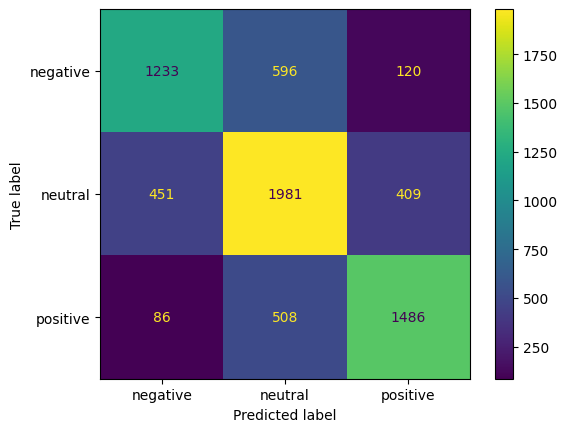

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(sentiment_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels = text_classifier.classes_)

# visualizing the results
disp.plot()
plt.show()


I would say the results are okay. The yellow and green colors are in the correctly predicted spots. There are also wrong results and this seems to vizualize the 70% accuracy quite well. The totally wrong answers are the smallest group which is good.

# My own sentences
The negative results didn't come as easily as I thought, so I added an extra "extremely negative" group to test it more.

In [ ]:
print("My positive sentences were predicted as: ",
      text_classifier.predict(["I feel great today."]),
      text_classifier.predict(["Finland won ice hockey."]), # this one was funny :)
      text_classifier.predict(["I am drinking my favourite drink."])
      )

print("My neutral sentences were predicted as: ",
      text_classifier.predict(["Hello world"]),
      text_classifier.predict(["I turn the light off at night."]),
      text_classifier.predict(["I am watching the news."])
      )

print("My negative sentences were predicted as: ",
      text_classifier.predict(["Sweden won ice hockey."]),
      text_classifier.predict(["I stepped in water with socks."]),
      text_classifier.predict(["I had 3 hours of sleep last night."])
      )

print("My extremely negative sentences were predicted as: ",
      text_classifier.predict(["I feel like shouting at everyone."]),
      text_classifier.predict(["I want to punch the wall."]),
      text_classifier.predict(["My aunt's dog dies today."])
      )

My positive sentences were predicted as:  ['positive'] ['negative'] ['positive']
My neutral sentences were predicted as:  ['neutral'] ['neutral'] ['neutral']
My negative sentences were predicted as:  ['neutral'] ['neutral'] ['neutral']
My extremely negative sentences were predicted as:  ['negative'] ['negative'] ['negative']
